# Calculation of average membrane height
In this notebook we calculate the average membrane height around the monomers during a simulation to see the effect of the upper amphipathic helix

In [1]:
import os
import sys
sys.path.insert(1, f'../../functions')
from functions import *

# Functions

In [2]:
con = np.load('../../DRMSD_reference/CV_connections/connections.npy')
monA = np.arange(con[0][0], con[-1][0]+1).astype(int)
monB = np.arange(con[0][1], con[-1][1]+1).astype(int)

def com_mon(traj:md.Trajectory, monA_index:np.array, monB_index:np.array, only_com=False):
    """Only make molecules whole

        Parameters
        ----------
        traj : mdtraj.Trajectory
            A mdtraj trajectory in which you want to calculate the distance between two center of masses
            
        monA_index : numpy array of shape (n_atoms, ) of the atom indecies you want to include
            The index of the atoms from which you want to calculate the center of mass (beginning from 0)
            
        monB_index : numpy array of shape (n_atoms, ) of the atom indecies you want to include
            The index of the atoms from which you want to calculate the center of mass (beginning from 0)
            

        --------
        """
    
    sorted_bonds = np.empty(shape=[0,2], dtype='int32')
    for i in monA_index:
        sorted_bonds = np.append(sorted_bonds, np.array([[i, i+1]], dtype='int32'), axis=0)
    for i in monB_index:
        sorted_bonds = np.append(sorted_bonds, np.array([[i, i+1]], dtype='int32'), axis=0)
    
    traj = traj.make_molecules_whole(sorted_bonds=sorted_bonds, inplace=False)
    
    monA = md.compute_center_of_mass(traj.atom_slice(monA_index))
    monB = md.compute_center_of_mass(traj.atom_slice(monB_index))
    
    return monA, monB

# Definitions

In [3]:
# save path for plots and h5 files
pickles = mkdir('pickles/membrane_height')
plots = mkdir('plots')

# Center and align trajectory

In [70]:
# Definitions
folder = f'../../systems/full_elastic_network/POPC100'
trr = f'{folder}/initial/prun.trr'
gro = f'{folder}/initial/prun.gro'
top = f'{folder}/topol.top'
temp = mkdir('temp')

command = (f'a 1-52\n'
           f'name 16 monA\n'
           f'a 188-239\n'
           f'name 17 monB\n'
           f'q')

# Create tpr and ndx file for centering
trun(f'gmx_mpi make_ndx -f {gro} -o {temp}/temp.ndx -nobackup <<EOF\n{command}EOF', open_terminal=True)
trun(f'gmx_mpi grompp -f {folder}/run.mdp -c {gro} -p {top} -o {temp}/temp.tpr -nobackup', open_terminal=True)

In [71]:
# Center trajectory around monomer 1 and monomer 2 respectively 
trun(f'gmx_mpi trjconv -f {trr} -n {temp}/temp.ndx -center -pbc mol '
    f'-s {temp}/temp.tpr -o {temp}/prun_center_monA.xtc -nobackup <<EOF\n16\n0\nEOF', open_terminal=True)
trun(f'gmx_mpi trjconv -f {trr} -n {temp}/temp.ndx -center -pbc mol '
    f'-s {temp}/temp.tpr -o {temp}/prun_center_monB.xtc -nobackup <<EOF\n17\n0\nEOF', open_terminal=True)

In [72]:
# align trajectory around monomer 1 and monomer 2 respectively 
trun(f'gmx_mpi trjconv -f {temp}/prun_center_monA.xtc -n {temp}/temp.ndx -fit rotxy+transxy '
    f'-s {temp}/temp.tpr -o {temp}/prun_align_monA.xtc -nobackup <<EOF\n16\n0\nEOF', open_terminal=True)
trun(f'gmx_mpi trjconv -f {temp}/prun_center_monB.xtc -n {temp}/temp.ndx -fit rotxy+transxy '
    f'-s {temp}/temp.tpr -o {temp}/prun_align_monB.xtc -nobackup <<EOF\n17\n0\nEOF', open_terminal=True)

# Analysing lipid hight during Ire1 simulation

In [24]:
# loading in trajectory
name = 'monA'
traj = md.load(f'temp/prun_center_{name}.xtc', top=gro)[-1800:]

In [48]:
# getting index from the NC3 atoms of POPC in the upper leaflet
structure_list = [line.strip('\n').split('NC3')[1].split()[0]
                  for line in open(f'{folder}/run.gro', 'r').readlines() 
                  if len(line.strip('\n').split('NC3')) == 2
                  if float(line.strip('\n').split()[-1]) >= 5.5]
POPC = np.asanyarray(structure_list, dtype=int)

# getting xyz coordinates of NC3 Atoms
traj_xyz = traj.atom_slice(POPC).xyz
traj_POPC = traj_xyz[-600:, :, :]

com_monA, com_monA2 =  com_mon(traj, [0, 2], [49, 51])
com_monB, com_monB2 =  com_mon(traj, [187, 189], [236, 238])

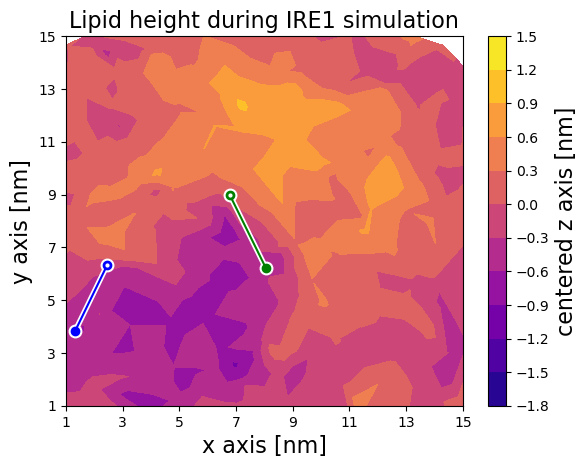

In [49]:
## Check plot for video

# Definition
k = 20
x = traj_POPC[k][:, 0]
y = traj_POPC[k][:, 1]
z = traj_POPC[k][:, 2] - np.mean(traj_POPC[k][:, 2])

## plot
fig, ax = plt.subplots()


# Contour plot
im1 = ax.tricontourf(x, y, z, vmin=-1.8, vmax=1.5, levels=np.arange(-1.8, 1.6, 0.3), cmap='plasma')
cbar = plt.colorbar(im1, ticks=np.arange(-1.8, 1.6, 0.3), extend='both').set_label(label = 'centered z axis [nm]', size=16)

# Plot the amphipathic helic
plt.plot([com_monA[k][0], com_monA2[k][0]],
          [com_monA[k][1], com_monA2[k][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
plt.plot([com_monA[k][0], com_monA2[k][0]],
          [com_monA[k][1], com_monA2[k][1]], color='green', linestyle='-', marker='o')
plt.plot([com_monA2[k][0]],
      [com_monA2[k][1]], color='white', linestyle='', marker='o', markersize=2)
plt.plot([com_monB[k][0], com_monB2[k][0]],
          [com_monB[k][1], com_monB2[k][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
plt.plot([com_monB[k][0], com_monB2[k][0]],
          [com_monB[k][1], com_monB2[k][1]], color='blue', linestyle='-', marker='o')
plt.plot([com_monB2[k][0]],
      [com_monB2[k][1]], color='white', linestyle='', marker='o', markersize=2)

## axis
plt.title('Lipid height during IRE1 simulation', fontsize=16)
plt.xlabel('x axis [nm]', fontsize=16)
plt.ylabel('y axis [nm]', fontsize=16)
plt.xlim(1, 15)
plt.ylim(1, 15)
plt.xticks(np.arange(1, 16, 2))
plt.yticks(np.arange(1, 16, 2))
plt.show()

In [50]:
# Create a directory to save images
if not os.path.exists('___temp___'):
    os.makedirs('___temp___')

# Generate and save multiple frames
for k in np.arange(len(traj_POPC)):
    
    # Definition
    x = traj_POPC[k][:, 0]
    y = traj_POPC[k][:, 1]
    z = traj_POPC[k][:, 2] - np.mean(traj_POPC[k][:, 2])

    ## plot
    fig, ax = plt.subplots()

    # Contour plot
    im1 = ax.tricontourf(x, y, z, vmin=-1.8, vmax=1.5, levels=np.arange(-1.8, 1.6, 0.3), cmap='plasma')
    cbar = plt.colorbar(im1, ticks=np.arange(-1.8, 1.6, 0.3), extend='both').set_label(label = 'centered z axis [nm]', size=16)

    # Plot the amphipathic helic
    plt.plot([com_monA[k][0], com_monA2[k][0]],
              [com_monA[k][1], com_monA2[k][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
    plt.plot([com_monA[k][0], com_monA2[k][0]],
              [com_monA[k][1], com_monA2[k][1]], color='green', linestyle='-', marker='o')
    plt.plot([com_monA2[k][0]],
          [com_monA2[k][1]], color='white', linestyle='', marker='o', markersize=2)
    plt.plot([com_monB[k][0], com_monB2[k][0]],
              [com_monB[k][1], com_monB2[k][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
    plt.plot([com_monB[k][0], com_monB2[k][0]],
              [com_monB[k][1], com_monB2[k][1]], color='blue', linestyle='-', marker='o')
    plt.plot([com_monB2[k][0]],
          [com_monB2[k][1]], color='white', linestyle='', marker='o', markersize=2)

    ## axis
    plt.title(f'Lipid height during IRE1 simulation ({name})', fontsize=16)
    plt.xlabel('x axis [nm]', fontsize=16)
    plt.ylabel('y axis [nm]', fontsize=16)
    plt.xlim(2, 14)
    plt.ylim(2, 14)
    plt.xticks(np.arange(1, 16, 2))
    plt.yticks(np.arange(1, 16, 2))

    # Save the figure as an image
    image_path = f'___temp___/frame_{k:03d}.png'
    plt.savefig(image_path)
    plt.close(fig)

# Prepare video writer
first_frame = cv2.imread('___temp___/frame_000.png')
height, width, _ = first_frame.shape
out = cv2.VideoWriter(f'{plots}/Bilayer_height_{name}.avi', cv2.VideoWriter_fourcc(*'DIVX'), 10, (width, height))

# Read and write each frame to the video
for i in np.arange(0, k+1):
    frame = cv2.imread(f'___temp___/frame_{i:03d}.png')
    out.write(frame)

# Release the video writer
out.release()

# Clean up the frames
for i in np.arange(0, k+1):
    os.remove(f'___temp___/frame_{i:03d}.png')
os.rmdir('___temp___')

## Mean Value

In [78]:
name = 'monB'
traj = md.load(f'temp/prun_align_{name}.xtc', top=gro)

In [80]:
# getting index from the NC3 atoms of POPC in the upper leaflet
structure_list = [line.strip('\n').split('NC3')[1].split()[0]
                  for line in open(f'{folder}/run.gro', 'r').readlines() 
                  if len(line.strip('\n').split('NC3')) == 2
                  if float(line.strip('\n').split()[-1]) >= 5.5]
POPC = np.asanyarray(structure_list, dtype=int)

# getting xyz coordinates of 
traj_POPC = traj.atom_slice(POPC).xyz

# calculating tip and back of amphipathic helix
amphi_monA, amphi_monA2 =  com_mon(traj, [0, 2], [49, 51])
amphi_monB, amphi_monB2 =  com_mon(traj, [187, 189], [236, 238])
pkl_save(f'{pickles}/amphipathic_helix_{name}.h5', [amphi_monA, amphi_monA2, amphi_monB, amphi_monB2])

In [81]:
# round xy axis to grid and center z axis
traj_clean = np.zeros(traj_POPC.shape, dtype='float32')
for i in np.arange(len(traj_POPC)):
    traj_clean[i][:, 0] = np.round(traj_POPC[i][:,0], 1)
    traj_clean[i][:, 1] = np.round(traj_POPC[i][:,1], 1)
    traj_clean[i][:, 2] = traj_POPC[i][:,2] - np.mean(traj_POPC[i][:,2])
traj_clean = np.concatenate(traj_clean)

# order z value by xy values
order_dir = {}
for i in tqdm(np.arange(len(traj_clean))):
    tx = str(traj_clean[i][0])
    ty = str(traj_clean[i][1])
    if f'{tx}_{ty}' not in list(order_dir.keys()):
        order_dir[f'{tx}_{ty}'] = [traj_clean[i][2]]
    else:
        order_dir[f'{tx}_{ty}'].append(traj_clean[i][2])

# calculate mean height in grid
mean_hight = []
for i in tqdm(order_dir):
    x, y = i.split('_')
    mean_hight.append([float(x), float(y), np.mean(order_dir[i])])
mean_hight = np.asanyarray(mean_hight)
pkl_save(f'{pickles}/mean_hight_{name}.h5', mean_hight)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 37128/37128 [00:00<00:00, 53408.54it/s]


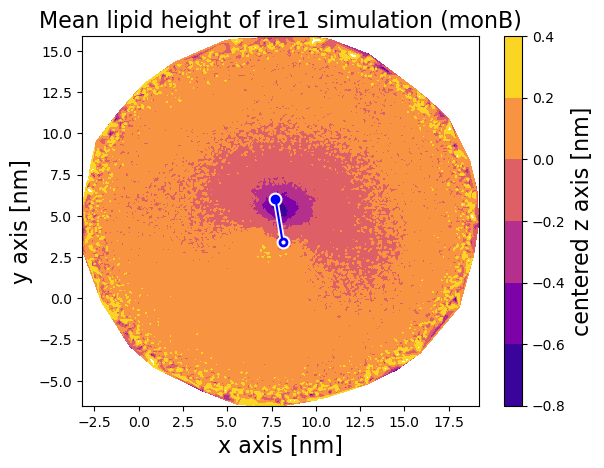

In [84]:
## Plot mean Lipid hight

# load pkl
name = 'monB'
amphi = True
mean_hight = pkl_load(f'{pickles}/mean_hight_{name}.h5')
cA, cA2, cB, cB2 = pkl_load(f'{pickles}/amphipathic_helix_{name}.h5')

# Definition
x = mean_hight[:, 0]
y = mean_hight[:, 1]
z = mean_hight[:, 2]

## plot
fig, ax = plt.subplots()

# Contour plot
im1 = ax.tricontourf(x, y, z, vmin=-0.8, vmax=0.4, levels=np.arange(-0.8, 0.5, 0.2), cmap='plasma')
cbar = plt.colorbar(im1, extend='both').set_label(label = 'centered z axis [nm]', size=16)

# Plot the amphipathic helic
if name == 'monA' and amphi == True:
    plt.plot([cA[0][0], cA2[0][0]],
              [cA[0][1], cA2[0][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
    plt.plot([cA[0][0], cA2[0][0]],
              [cA[0][1], cA2[0][1]], color='green', linestyle='-', marker='o')
    plt.plot([cA2[0][0]],
              [cA2[0][1]], color='white', linestyle='', marker='o', markersize=2)
    
elif name == 'monB' and amphi == True:
    plt.plot([cB[0][0], cB2[0][0]],
              [cB[0][1], cB2[0][1]], color='white', linestyle='-', marker='o', markersize=9, linewidth=4)
    plt.plot([cB[0][0], cB2[0][0]],
              [cB[0][1], cB2[0][1]], color='blue', linestyle='-', marker='o')
    plt.plot([cB2[0][0]],
             [cB2[0][1]], color='white', linestyle='', marker='o', markersize=2)

## axis
plt.title(f'Mean lipid height of ire1 simulation ({name})', fontsize=16)
plt.xlabel('x axis [nm]', fontsize=16)
plt.ylabel('y axis [nm]', fontsize=16)
plt.savefig(f'{plots}/mean_lipid_hight_{name}_2.pdf')
plt.show()